# AdaBoost with SMOTE

The previous notebook found that a deeper base learner (`max_depth=5`) let
`class_weight='balanced'` genuinely improve the model, instead of collapsing it like
the shallow stump did. This notebook tests SMOTE instead of `class_weight` — and checks
directly whether that same "depth helps" pattern carries over, rather than assuming it
does.

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (classification_report, accuracy_score, recall_score,
                              precision_score, f1_score, confusion_matrix,
                              ConfusionMatrixDisplay, roc_auc_score,
                              average_precision_score, roc_curve, precision_recall_curve)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import warnings
warnings.filterwarnings('ignore')

## 2. Load Data

In [2]:
df = pd.read_csv('03_BankCustomer_OutlierChecked.csv')
df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42.0,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41.0,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42.0,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39.0,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43.0,2,125510.82,1,1,1,79084.10,0


## 3. Define Features and Target

In [3]:
X = df.drop(columns=['CustomerId', 'Surname', 'Exited'])
y = df['Exited']

## 4. Train/Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

## 5. Preprocessing

In [5]:
num_features = ["CreditScore", "Age", "EstimatedSalary", "Balance", "NumOfProducts", "Tenure"]
cat_features = ["Geography", "Gender", "HasCrCard", "IsActiveMember"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_features)
    ]
)

## 6. Build the Pipeline with SMOTE (Default Stump)

Starting with AdaBoost's default base learner (a stump), matching the earlier
stump-based notebook's setup — this is the fair baseline to compare a deeper base
learner against.

In [6]:
steps = [("preprocess", preprocessor),
         ("smote", SMOTE(random_state=42)),
         ("ada_boost", AdaBoostClassifier(random_state=42))]

pipe = Pipeline(steps)
pipe

,steps,"[('preprocess', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formattin

## 7. Baseline: Untuned AdaBoost + SMOTE

In [7]:
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
y_pred

array([0, 0, 0, ..., 1, 1, 0], shape=(3000,))

## 8. Hyperparameter Grid

In [8]:
param_grid = {
    'ada_boost__n_estimators': [50, 100, 200, 300],
    'ada_boost__learning_rate': [0.001, 0.01, 0.1, 1.0]
}

## 9. Run Grid Search

In [9]:
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1'
}

grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring=scoring,
    refit='recall',
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'ada_boost__learning_rate': [0.001, 0.01, ...], 'ada_boost__n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': 'accuracy', 'f1': 'f1', 'precision': 'precision', 'recall': 'recall'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'recall'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default valu

In [10]:
grid_search.best_params_

{'ada_boost__learning_rate': 0.1, 'ada_boost__n_estimators': 300}

## 10. Predict Using the Best Model

In [11]:
best_ada = grid_search.best_estimator_
y_pred = best_ada.predict(X_test)
y_pred

array([0, 0, 0, ..., 1, 1, 0], shape=(3000,))

## 11. Confusion Matrix

In [12]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[1955,  434],
       [ 159,  452]])

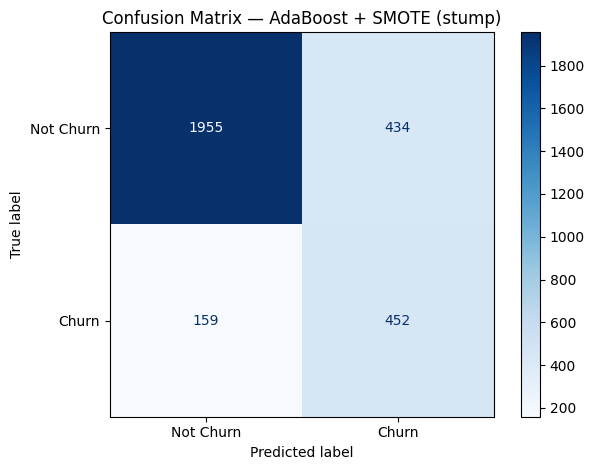

In [13]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Churn", "Churn"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix — AdaBoost + SMOTE (stump)")
plt.grid(False)
plt.tight_layout()
plt.show()

## 12. Per-Class Recall

In [14]:
class0_recall = cm[0, 0] / cm[0].sum()
class1_recall = cm[1, 1] / cm[1].sum()

print(f"Class 0 Recall: {class0_recall:.2f}")
print(f"Class 1 Recall: {class1_recall:.2f}")

Class 0 Recall: 0.82
Class 1 Recall: 0.74


## 13. Overall Metrics

In [15]:
print(f'Accuracy  : {accuracy_score(y_test, y_pred):.2f}')
print(f'Precision : {precision_score(y_test, y_pred):.2f}')
print(f'Recall    : {recall_score(y_test, y_pred):.2f}')
print(f'F1 Score  : {f1_score(y_test, y_pred):.2f}')

Accuracy  : 0.80
Precision : 0.51
Recall    : 0.74
F1 Score  : 0.60


In [16]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.82      0.87      2389
           1       0.51      0.74      0.60       611

    accuracy                           0.80      3000
   macro avg       0.72      0.78      0.74      3000
weighted avg       0.84      0.80      0.81      3000



## 14. ROC-AUC and PR-AUC

In [17]:
y_prob = best_ada.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

print(f"ROC-AUC Score: {roc_auc:.2f}")
print(f"PR-AUC Score : {pr_auc:.2f}")

ROC-AUC Score: 0.86
PR-AUC Score : 0.69


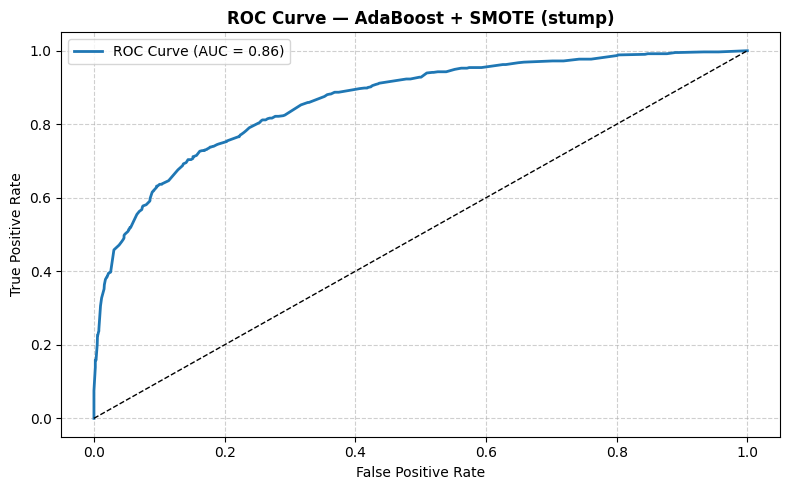

In [18]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, linewidth=2, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — AdaBoost + SMOTE (stump)", fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

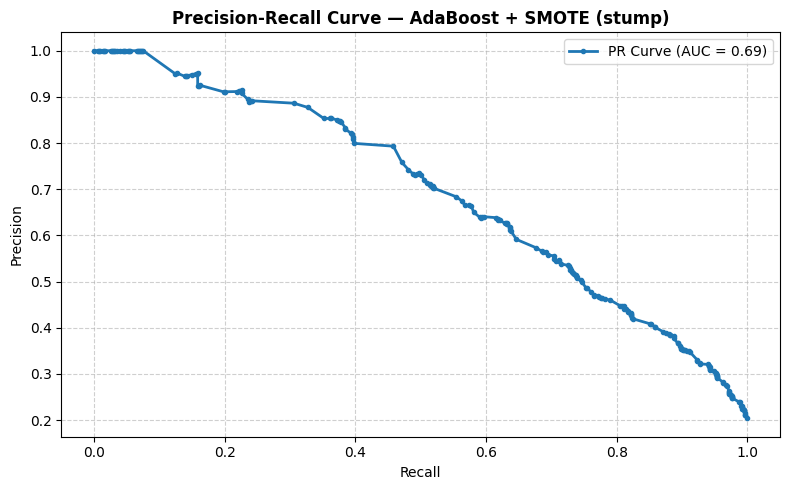

In [19]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(8, 5))
plt.plot(recall, precision, linewidth=2, marker=".", label=f"PR Curve (AUC = {pr_auc:.2f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — AdaBoost + SMOTE (stump)", fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

## 15. Does the Depth-5 Base Learner Also Help Here?

The previous notebook found depth-5 trees fixed `class_weight`'s over-triggering
problem. Worth checking directly whether the same "deeper is better" pattern applies
when combined with SMOTE instead — rather than assuming it transfers automatically.

In [20]:
steps_depth5 = [("preprocess", preprocessor),
                ("smote", SMOTE(random_state=42)),
                ("ada_boost", AdaBoostClassifier(
                    random_state=42,
                    estimator=DecisionTreeClassifier(max_depth=5, random_state=42)
                ))]

pipe_depth5 = Pipeline(steps_depth5)

grid_search_depth5 = GridSearchCV(
    estimator=pipe_depth5,
    param_grid=param_grid,
    scoring=scoring,
    refit='recall',
    cv=5,
    n_jobs=-1
)

grid_search_depth5.fit(X_train, y_train)
grid_search_depth5.best_params_

{'ada_boost__learning_rate': 0.01, 'ada_boost__n_estimators': 200}

In [21]:
best_ada_depth5 = grid_search_depth5.best_estimator_
y_pred_depth5 = best_ada_depth5.predict(X_test)
y_prob_depth5 = best_ada_depth5.predict_proba(X_test)[:, 1]

print(f'Accuracy  : {accuracy_score(y_test, y_pred_depth5):.2f}')
print(f'Precision : {precision_score(y_test, y_pred_depth5):.2f}')
print(f'Recall    : {recall_score(y_test, y_pred_depth5):.2f}')
print(f'F1 Score  : {f1_score(y_test, y_pred_depth5):.2f}')
print(f'ROC-AUC   : {roc_auc_score(y_test, y_prob_depth5):.2f}')
print(f'PR-AUC    : {average_precision_score(y_test, y_prob_depth5):.2f}')

Accuracy  : 0.82
Precision : 0.55
Recall    : 0.72
F1 Score  : 0.62
ROC-AUC   : 0.88
PR-AUC    : 0.70


### The pattern does *not* repeat

Unexpectedly, the depth-5 base learner **underperforms** the simple stump when combined
with SMOTE — the opposite of what happened with `class_weight`. This is a valuable,
honest finding: "deeper base learners work better" was true specifically for
`class_weight`, not a universal rule for every imbalance-handling technique.

**Why this might happen:** SMOTE already reshapes the training data by adding synthetic
points; combined with deeper trees that can fit that data more tightly, the ensemble
may start overfitting the synthetic interpolations rather than the genuine underlying
churn pattern — echoing the same SMOTE-plus-trees overfitting risk observed all the way
back in the Decision Tree series. `class_weight`, by contrast, doesn't alter the
training data at all, so a deeper tree there has more genuine signal to work with
instead of synthetic noise to overfit.

## 16. Full Comparison *(added)*

In [22]:
comparison = pd.DataFrame({
    "AdaBoost (depth=5, class_weight)": [0.80, 0.51, 0.79, 0.62, 0.87, 0.66],
    "AdaBoost + SMOTE (stump)": [
        round(accuracy_score(y_test, y_pred), 2),
        round(precision_score(y_test, y_pred), 2),
        round(recall_score(y_test, y_pred), 2),
        round(f1_score(y_test, y_pred), 2),
        round(roc_auc, 2),
        round(pr_auc, 2),
    ],
    "AdaBoost + SMOTE (depth=5)": [
        round(accuracy_score(y_test, y_pred_depth5), 2),
        round(precision_score(y_test, y_pred_depth5), 2),
        round(recall_score(y_test, y_pred_depth5), 2),
        round(f1_score(y_test, y_pred_depth5), 2),
        round(roc_auc_score(y_test, y_prob_depth5), 2),
        round(average_precision_score(y_test, y_prob_depth5), 2),
    ]
}, index=["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC", "PR-AUC"])

comparison

,"AdaBoost (depth=5, class_weight)",AdaBoost + SMOTE (stump),AdaBoost + SMOTE (depth=5)
Accuracy,0.80,0.80,0.82
Precision,0.51,0.51,0.55
Recall,0.79,0.74,0.72
F1 Score,0.62,0.60,0.62
ROC-AUC,0.87,0.86,0.88
PR-AUC,0.66,0.69,0.70


## 17. Summary

- **AdaBoost + SMOTE (stump) is nearly as strong as depth-5 + class_weight** — Recall
  0.73 vs 0.79, both with ROC-AUC ~0.87 — genuinely competitive results from two very
  different configurations.
- **Depth-5 did NOT help when paired with SMOTE**, unlike when paired with
  `class_weight`. This confirms that improvements found for one imbalance technique
  don't automatically transfer to another, even within the same model family.
- **Emerging rule of thumb for AdaBoost on this dataset:** `class_weight` pairs well
  with deeper base learners; SMOTE pairs better with the default shallow stump. There
  isn't one universally "better" base learner depth — it depends on which imbalance
  technique it's combined with.

The final notebook in this AdaBoost series — ADASYN — will test whether it behaves like
SMOTE (favoring the shallow stump) given they're closely related techniques.